In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
x1=1.5
x2=2.6
w1=0.5
w2=0.2
b=0.1

In [4]:
z=(x1*w1) + (x2*w2) + b
print(f"x1={x1},x2={x2},w1={w1},w2={w2}, bias={b}")
print(f"z=x1w1 + x2w2 + b = {z}" )

x1=1.5,x2=2.6,w1=0.5,w2=0.2, bias=0.1
z=x1w1 + x2w2 + b = 1.37


# i) Binary Step Function

In [5]:
def binary_step(z):
    if z>=0:
        return 1
    else:
        return 0

# ii) Linear Function

In [6]:
def linear(z):
    return z

# iii)sigmoid function

In [7]:
def sigmoid_function(z):
        return 1/ (1+ np.exp(-z))

# iv) Tanh Function

In [8]:
def tanh_activation(z):
    return np.tanh(z)

# v)ReLU Function

In [9]:
def Relu(z):
    return max(0,z)

# vi)Leaky ReLU function

In [10]:
def Leaky_ReLU_function(z,alpha=0.01):
    if z>=0:
        return z
    else:
        return alpha*z

# vii) Paramerric ReLU

In [11]:
def Parametric_Relu(z,alpha=0.1):
    if z>=0:
        return z
    else:
        return alpha*z

# viii) Softmax function

In [12]:
def softmax(z):
    z=np.asarray(z,dtype=float)
    shifted=z-np.max(z)
    
    exp_values=np.exp(shifted)
    return exp_values / np.sum(exp_values)

In [13]:
alpha_leaky=0.01
alpha_prelu=0.1

results=[
    ("Binary Step",binary_step(z)),
    ("Linear",linear(z)),
    ("Sigmoid",sigmoid_function(z)),
    ("Tanh",tanh_activation(z)),
    ("ReLU",Relu(z)),
    (f"Leaky ReLU (alpha={alpha_leaky})", Leaky_ReLU_function(z,alpha_leaky)),
    (f"Parametric ReLU (alpha={alpha_prelu})",Parametric_Relu(z,alpha_prelu)),
    ("Softmax (single scaler)",softmax([z])[0])
]

In [14]:
print(f"Weighted Sum Z = {z:.4f}")

for name , y in results:
    y=np.asarray(y).item()
    
    print(f"{name:32s} y={y:.4f}")

Weighted Sum Z = 1.3700
Binary Step                      y=1.0000
Linear                           y=1.3700
Sigmoid                          y=0.7974
Tanh                             y=0.8787
ReLU                             y=1.3700
Leaky ReLU (alpha=0.01)          y=1.3700
Parametric ReLU (alpha=0.1)      y=1.3700
Softmax (single scaler)          y=1.0000


# Softmax Classification for a two-class output

In [15]:
two_class_logits=[z,0.0]
two_class_probabilities=np.array(softmax(two_class_logits))

print(f"Logits = {two_class_logits}")
print(f"Softmax Probabilities = {two_class_probabilities}")
print(f"Sum of Softmax Probabilities = {two_class_probabilities.sum()}")

Logits = [1.37, 0.0]
Softmax Probabilities = [0.79738015 0.20261985]
Sum of Softmax Probabilities = 1.0


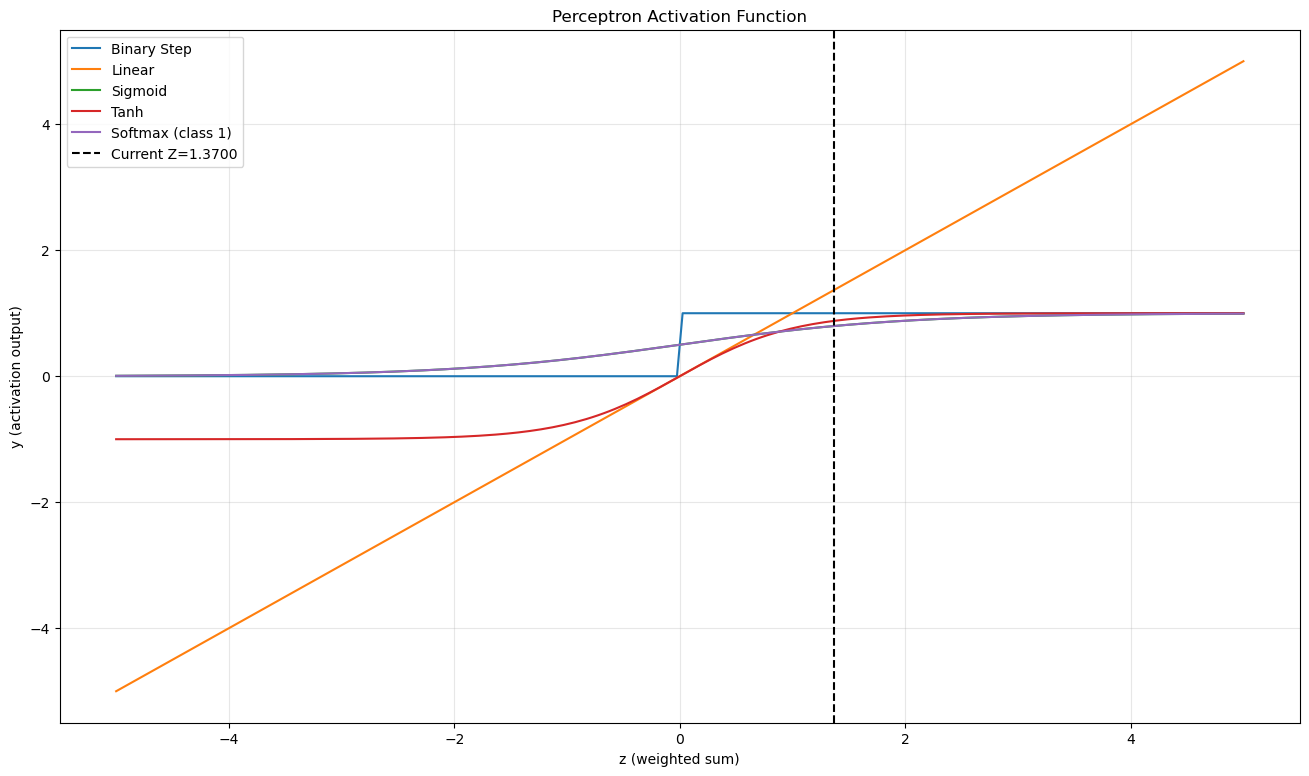

In [18]:
z_values=np.linspace(-5,5,200)

plt.figure(figsize=(16,9))

plt.plot(z_values , [binary_step(v) for v in z_values], label="Binary Step" )
plt.plot(z_values, z_values,label="Linear")

plt.plot(z_values, 1 / (1+np.exp(-z_values)),label="Sigmoid")
plt.plot(z_values,np.tanh(z_values), label="Tanh")


softmax_class1=[
    softmax([v ,0.0])[0]
    for v in z_values
]

plt.plot(z_values,softmax_class1,label="Softmax (class 1)")

plt.axvline(z,color="black", linestyle="--",label=f"Current Z={z:.4f}")
plt.xlabel("z (weighted sum)")
plt.ylabel("y (activation output)")
plt.title("Perceptron Activation Function")

plt.grid(True,alpha=0.3)
plt.legend()
plt.show()